In [ ]:
# 1. Install required packages for BigQuery and data handling
!pip install google-cloud-bigquery db-dtypes google-auth==2.49.0 pandas==2.2.3 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.7/240.7 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 49.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from google.cloud import bigquery
from google.colab import auth

In [ ]:
# 2. Authenticate user in Google Colab
auth.authenticate_user()
print("Authenticated successfully to Google Cloud!")

Authenticated successfully to Google Cloud!


In [ ]:
# ==========================================
# CONFIGURATION: Update with your GCP Project ID
# ==========================================
PROJECT_ID = "banking-customer-transaction"
DATASET_ID = "banking_warehouse"

# Initialize BigQuery client (Colab will prompt you to authenticate with Google)
client = bigquery.Client(project=PROJECT_ID)

In [ ]:
# ==========================================
# 3. GENERATE MOCK DATA
# ==========================================
np.random.seed(42)
n_customers = 500
n_transactions = 5000

# Customers Table
customers_df = pd.DataFrame(
    {
        "customer_id": [f"CUST_{i:04d}" for i in range(1, n_customers + 1)],
        "signup_date": pd.date_range(
            start="2024-01-01", periods=n_customers, freq="D"
        ).strftime("%Y-%m-%d"),
        "customer_segment": np.random.choice(
            ["VIP / High Value", "Mid Tier", "Standard"],
            size=n_customers,
            p=[0.1, 0.3, 0.6],
        ),
    }
)

In [ ]:
# Transactions Table
transactions_df = pd.DataFrame(
    {
        "transaction_id": [f"TXN_{i:06d}" for i in range(1, n_transactions + 1)],
        "customer_id": np.random.choice(
            customers_df["customer_id"], size=n_transactions
        ),
        "transaction_amount": np.round(
            np.random.exponential(scale=250, size=n_transactions), 2
        ),
        "transaction_date": pd.date_range(
            start="2025-01-01", periods=n_transactions, freq="h"
        ).strftime("%Y-%m-%d %H:%M:%S"),
        "product_category": np.random.choice(
            ["Retail", "Electronics", "Groceries", "Travel", "Utilities"],
            size=n_transactions,
        ),
    }
)

print("--- Mock Data Preview ---")
display(customers_df.head(3))
display(transactions_df.head(3))

--- Mock Data Preview ---


,customer_id,signup_date,customer_segment
0,CUST_0001,2024-01-01,Mid Tier
1,CUST_0002,2024-01-02,Standard
2,CUST_0003,2024-01-03,Standard


,transaction_id,customer_id,transaction_amount,transaction_date,product_category
0,TXN_000001,CUST_0447,24.15,2025-01-01 00:00:00,Travel
1,TXN_000002,CUST_0145,228.48,2025-01-01 01:00:00,Travel
2,TXN_000003,CUST_0201,244.31,2025-01-01 02:00:00,Groceries


In [ ]:
# ==========================================
# 4. UPLOAD TO GCP BIGQUERY
# ==========================================
dataset_ref = client.dataset(DATASET_ID)

try:
  client.get_dataset(dataset_ref)
  print(f"Dataset '{DATASET_ID}' already exists.")
except Exception:
  dataset = bigquery.Dataset(dataset_ref)
  dataset.location = "US"
  client.create_dataset(dataset)
  print(f"Dataset '{DATASET_ID}' created successfully.")

job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")

# Upload Customers Table
cust_table_ref = dataset_ref.table("customers")
client.load_table_from_dataframe(
    customers_df, cust_table_ref, job_config=job_config
).result()
print("-> Uploaded 'customers' table to BigQuery!")

# Upload Transactions Table
txn_table_ref = dataset_ref.table("transactions")
client.load_table_from_dataframe(
    transactions_df, txn_table_ref, job_config=job_config
).result()
print("-> Uploaded 'transactions' table to BigQuery!")
print("\n🎉 GCP Data Pipeline Complete!")

Dataset 'banking_warehouse' created successfully.
-> Uploaded 'customers' table to BigQuery!
-> Uploaded 'transactions' table to BigQuery!

🎉 GCP Data Pipeline Complete!


In [ ]:
from google.cloud import bigquery
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

# Connect and query processed data from BigQuery
client = bigquery.Client(project="banking-customer-transaction")
query = """
    SELECT
        c.customer_segment,
        t.product_category,
        t.transaction_amount
    FROM `banking-customer-transaction.banking_warehouse.transactions` t
    JOIN `banking-customer-transaction.banking_warehouse.customers` c
        ON t.customer_id = c.customer_id
"""
df = client.query(query).to_dataframe()

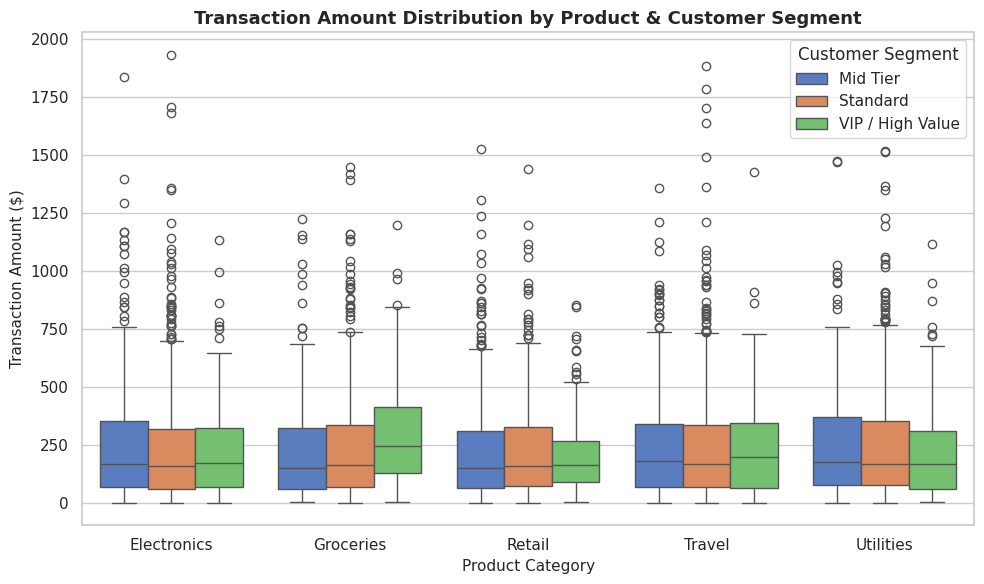

In [ ]:
# Plot spending behavior across categories and segments
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df, x='product_category', y='transaction_amount', hue='customer_segment', palette='muted')
plt.title('Transaction Amount Distribution by Product & Customer Segment', fontsize=13, fontweight='bold')
plt.xlabel('Product Category', fontsize=11)
plt.ylabel('Transaction Amount ($)', fontsize=11)
plt.legend(title='Customer Segment')
plt.tight_layout()
plt.show()